In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load dataset
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

In [4]:
# Display dataset information
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [7]:
# Separate features and target variable
housing=fetch_california_housing()
df=pd.DataFrame(housing.data,columns=housing.feature_names)
df['Price']=housing.target
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


In [8]:
# Split dataset into training and testing sets
X=df.drop('Price',axis=1)
y=df['Price']

In [9]:
# Create machine learning model
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
# Train the model
model=LinearRegression()

In [11]:
# Make predictions
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
# Evaluate model performance
y_pred=model.predict(X_test)

In [13]:
# Visualize results
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

In [15]:
# Visualize results
print("Model Performance")
print("-------------------")
print("MAE:",mae)
print("MSE:",mse)
print("R2 Score:",r2)

Model Performance
-------------------
MAE: 0.5332001304956555
MSE: 0.5558915986952441
R2 Score: 0.575787706032451


In [17]:
# Visualize results
coefficients = pd.DataFrame({
    'Feature' : X.columns,
    'Coefficient' : model.coef_
})
print(coefficients)

      Feature  Coefficient
0      MedInc     0.448675
1    HouseAge     0.009724
2    AveRooms    -0.123323
3   AveBedrms     0.783145
4  Population    -0.000002
5    AveOccup    -0.003526
6    Latitude    -0.419792
7   Longitude    -0.433708


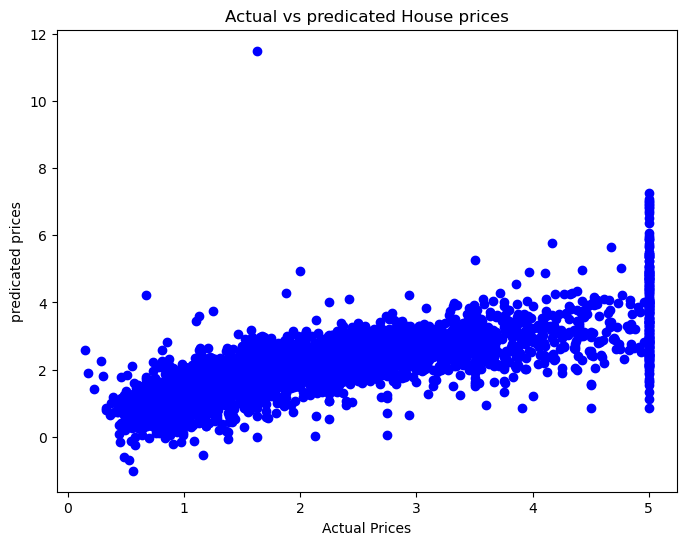

In [18]:
# Visualize results
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred,color='blue')
plt.xlabel("Actual Prices")
plt.ylabel("predicated prices")
plt.title("Actual vs predicated House prices")
plt.show()